# eDNA Pipeline - Data Visualization

Visualize output from both **Water** (18S + COI) and **Soil** (COI + JEDI) datasets:
- Table structure & headers
- Sequence length distributions (from consensus FASTA)
- OTU abundance distributions
- Taxonomic composition (Phylum → Species)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from Bio import SeqIO

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

BASE = Path(".")
WATER_DIR = BASE / "out" / "Water_eDNA_18S_COI_14_01_26"
SOIL_DIR = BASE / "out" / "Soil_eDNA_JEDI_COI_14_01_26"

## 1. Load All Datasets

In [ ]:
# Load comprehensive taxonomy tables
datasets = {}
files = {
    "Water_18S": WATER_DIR / "taxonomy_summary" / "comprehensive_taxonomy_18S.csv",
    "Water_COI": WATER_DIR / "taxonomy_summary" / "comprehensive_taxonomy_COI.csv",
    "Soil_COI":  SOIL_DIR  / "taxonomy_summary" / "comprehensive_taxonomy_COI.csv",
    "Soil_JEDI": SOIL_DIR  / "taxonomy_summary" / "comprehensive_taxonomy_JEDI.csv",
}

for name, path in files.items():
    if path.exists():
        datasets[name] = pd.read_csv(path)
        print(f"✓ {name}: {datasets[name].shape[0]} OTUs × {datasets[name].shape[1]} columns")
    else:
        print(f"✗ {name}: file not found")

# Load raw abundance matrices
abundance = {}
abund_files = {
    "Water_18S": WATER_DIR / "merged" / "otu_abundance_matrix_18S.csv",
    "Water_COI": WATER_DIR / "merged" / "otu_abundance_matrix_COI.csv",
    "Soil_COI":  SOIL_DIR  / "merged" / "otu_abundance_matrix_COI.csv",
    "Soil_JEDI": SOIL_DIR  / "merged" / "otu_abundance_matrix_JEDI.csv",
}

for name, path in abund_files.items():
    if path.exists():
        abundance[name] = pd.read_csv(path, index_col=0)
        print(f"✓ {name} abundance: {abundance[name].shape}")
    else:
        print(f"✗ {name} abundance: file not found")

# Auto-detect taxonomy column prefix per dataset (SILVA_ or MIDORI_)
# 18S uses SILVA, COI/JEDI use MIDORI2
def get_tax_prefix(df):
    """Detect whether taxonomy columns use SILVA_ or MIDORI_ prefix."""
    for col in df.columns:
        if col.startswith("SILVA_"):
            return "SILVA"
        if col.startswith("MIDORI_"):
            return "MIDORI"
    return "SILVA"  # fallback

tax_prefix = {}
for name, df in datasets.items():
    tax_prefix[name] = get_tax_prefix(df)
    print(f"  {name}: taxonomy prefix = {tax_prefix[name]}_*")

TAX_RANKS = ["Domain", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

def tax_col(dataset_name, rank):
    """Get the correct taxonomy column name for a dataset."""
    return f"{tax_prefix[dataset_name]}_{rank}"

✓ Water_18S: 59002 OTUs × 29 columns
✓ Water_COI: 6281 OTUs × 29 columns
✓ Soil_COI: 50858 OTUs × 33 columns
✓ Soil_JEDI: 22360 OTUs × 33 columns
✓ Water_18S abundance: (59002, 16)
✓ Water_COI abundance: (6281, 16)
✓ Soil_COI abundance: (50858, 20)
✓ Soil_JEDI abundance: (22360, 20)


## 2. Inspect Table Headers & Structure

In [ ]:
for name, df in datasets.items():
    prefix = tax_prefix[name]
    print(f"\n{'='*60}")
    print(f"  {name} ({prefix} database)  —  {df.shape[0]} OTUs × {df.shape[1]} columns")
    print(f"{'='*60}")
    
    # Column groups
    sample_cols = [c for c in df.columns if c.startswith("Sample_")]
    taxonomy_cols = [c for c in df.columns if c.startswith(f"{prefix}_") or c.startswith("NCBI_")]
    meta_cols = [c for c in df.columns if c not in sample_cols + taxonomy_cols]
    
    print(f"\nMetadata columns:  {meta_cols}")
    print(f"Sample columns:    {sample_cols}")
    print(f"Taxonomy columns:  {taxonomy_cols}")
    print(f"\nFirst 3 rows:")
    display(df.head(3))


  Water_18S  —  59002 OTUs × 29 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['SILVA_Domain', 'SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,SILVA_Domain,SILVA_Phylum,SILVA_Class,SILVA_Order,SILVA_Family,SILVA_Genus,SILVA_Species,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_18S_005421,0.766523,1,0.004390,0.095702,0.082278,0.099657,0.0,0.0,0.006094,...,Eukaryota,Ciliophora,Intramacronucleata,Spirotrichea,Oligotrichia,Strombidium,uncultured_ciliate,NaN,NaN,NaN
1,OTU_18S_000035,0.355367,2,0.020870,0.021060,0.004128,0.006171,0.0,0.0,0.028086,...,Eukaryota,Arthropoda,Insecta,Diptera,NaN,NaN,Anopheles_gambiae,NaN,NaN,NaN
2,OTU_18S_000362,0.310807,3,0.008224,0.016476,0.003853,0.005794,0.0,0.0,0.010984,...,Eukaryota,Arthropoda,Insecta,Odonata,NaN,NaN,Gluvia_dorsalis,NaN,NaN,NaN



  Water_COI  —  6281 OTUs × 29 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode06', 'Sample_barcode07', 'Sample_barcode08', 'Sample_barcode09', 'Sample_barcode10', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_unclassified']
Taxonomy columns:  ['SILVA_Domain', 'SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode06,Sample_barcode07,...,SILVA_Domain,SILVA_Phylum,SILVA_Class,SILVA_Order,SILVA_Family,SILVA_Genus,SILVA_Species,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000076,0.279448,1,0.021097,0.040323,0.042105,0.008237,0.0,0.0,0.01108,...,Eukaryota,Arthropoda,Insecta,Orthoptera,Acrididae,Melanoplus,Melanoplus,NaN,NaN,NaN
1,OTU_COI_005155,0.166667,2,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,Eukaryota,Arthropoda,Insecta,Coleoptera,Curculionidae,Melanterius,Melanterius,NaN,NaN,NaN
2,OTU_COI_005391,0.166667,3,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  Soil_COI  —  50858 OTUs × 33 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_barcode16', 'Sample_barcode17', 'Sample_barcode18', 'Sample_barcode19', 'Sample_barcode20', 'Sample_barcode21', 'Sample_barcode22', 'Sample_barcode23', 'Sample_barcode24', 'Sample_unclassified']
Taxonomy columns:  ['SILVA_Domain', 'SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode11,Sample_barcode12,...,SILVA_Domain,SILVA_Phylum,SILVA_Class,SILVA_Order,SILVA_Family,SILVA_Genus,SILVA_Species,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_COI_000813,0.187124,1,0.000000,0.0,0.000000,0.0,0.184679,0.0,0.0,...,Eukaryota,Ascomycota,Sordariomycetes,Hypocreales,Hypocreaceae,Cladobotryum,Cladobotryum,NaN,NaN,NaN
1,OTU_COI_000266,0.151618,2,0.127912,0.0,0.016154,0.0,0.000217,0.0,0.0,...,Eukaryota,Ascomycota,Sordariomycetes,Hypocreales,Ophiocordycipitaceae,Ophiocordyceps,Ophiocordyceps,NaN,NaN,NaN
2,OTU_COI_000722,0.127011,3,0.000000,0.0,0.000000,0.0,0.124566,0.0,0.0,...,Eukaryota,Bacillariophyta,Bacillariophyceae,Bacillariales,Bacillariaceae,Nitzschia,Nitzschia,NaN,NaN,NaN



  Soil_JEDI  —  22360 OTUs × 33 columns

Metadata columns:  ['OTU_ID', 'Total_Abundance', 'Rank']
Sample columns:    ['Sample_barcode01', 'Sample_barcode02', 'Sample_barcode03', 'Sample_barcode04', 'Sample_barcode05', 'Sample_barcode11', 'Sample_barcode12', 'Sample_barcode13', 'Sample_barcode14', 'Sample_barcode15', 'Sample_barcode16', 'Sample_barcode17', 'Sample_barcode18', 'Sample_barcode19', 'Sample_barcode20', 'Sample_barcode21', 'Sample_barcode22', 'Sample_barcode23', 'Sample_barcode24', 'Sample_unclassified']
Taxonomy columns:  ['SILVA_Domain', 'SILVA_Phylum', 'SILVA_Class', 'SILVA_Order', 'SILVA_Family', 'SILVA_Genus', 'SILVA_Species', 'NCBI_TopHit', 'NCBI_Identity', 'NCBI_Evalue']

First 3 rows:


,OTU_ID,Total_Abundance,Rank,Sample_barcode01,Sample_barcode02,Sample_barcode03,Sample_barcode04,Sample_barcode05,Sample_barcode11,Sample_barcode12,...,SILVA_Domain,SILVA_Phylum,SILVA_Class,SILVA_Order,SILVA_Family,SILVA_Genus,SILVA_Species,NCBI_TopHit,NCBI_Identity,NCBI_Evalue
0,OTU_JEDI_000731,0.061947,1,0.061947,0.00,0.0,0.0,0.000000,0.0,0.0,...,Eukaryota,Bacillariophyta,Bacillariophyceae,Naviculales,genus_Naviculales,NaN,NaN,NaN,NaN,NaN
1,OTU_JEDI_021962,0.060976,2,0.000000,0.00,0.0,0.0,0.060976,0.0,0.0,...,Eukaryota,Bacillariophyta,Bacillariophyceae,Rhopalodiales,Rhopalodiaceae,Rhopalodia,Rhopalodia,NaN,NaN,NaN
2,OTU_JEDI_020943,0.050000,3,0.000000,0.05,0.0,0.0,0.000000,0.0,0.0,...,Eukaryota,Arthropoda,Insecta,Coleoptera,Dermestidae,Orphinus,Orphinus,NaN,NaN,NaN


In [ ]:
# Summary statistics for each dataset
summary_rows = []
for name, df in datasets.items():
    phylum_col = tax_col(name, "Phylum")
    species_col = tax_col(name, "Species")
    sample_cols = [c for c in df.columns if c.startswith("Sample_") and c != "Sample_unclassified"]
    summary_rows.append({
        "Dataset": name,
        "Database": tax_prefix[name],
        "Total OTUs": df.shape[0],
        "Samples": len(sample_cols),
        "Has Taxonomy": df[phylum_col].notna().sum(),
        "% Assigned (Phylum)": f"{df[phylum_col].notna().mean()*100:.1f}%",
        "% Assigned (Species)": f"{df[species_col].notna().mean()*100:.1f}%",
    })

pd.DataFrame(summary_rows).set_index("Dataset")

,Total OTUs,Samples,Has Taxonomy,% Assigned (Phylum),% Assigned (Species)
Dataset,,,,,
Water_18S,59002,15,34480,58.4%,59.7%
Water_COI,6281,15,4162,66.3%,65.1%
Soil_COI,50858,19,29922,58.8%,57.4%
Soil_JEDI,22360,19,12103,54.1%,53.3%


## 3. Sequence Length Distributions (Consensus OTU sequences)

Shows the length distribution of consensus OTU sequences for each marker. Useful for identifying primer dimers, truncated reads, or off-target amplification.

In [5]:
# Parse consensus FASTA files and compute sequence lengths
fasta_files = {
    "Water_18S": WATER_DIR / "temp_clustering" / "consensus_18S_clean.fasta",
    "Water_COI": WATER_DIR / "temp_clustering" / "consensus_COI_clean.fasta",
    "Soil_COI":  SOIL_DIR  / "temp_clustering" / "consensus_COI_clean.fasta",
    "Soil_JEDI": SOIL_DIR  / "temp_clustering" / "consensus_JEDI_clean.fasta",
}

seq_lengths = {}
for name, path in fasta_files.items():
    if path.exists():
        lengths = [len(rec.seq) for rec in SeqIO.parse(str(path), "fasta")]
        seq_lengths[name] = lengths
        print(f"✓ {name}: {len(lengths)} sequences, median={np.median(lengths):.0f}bp, "
              f"range={min(lengths)}-{max(lengths)}bp")
    else:
        print(f"✗ {name}: FASTA not found")

✓ Water_18S: 35237 sequences, median=1853bp, range=1500-2809bp
✓ Water_COI: 4162 sequences, median=829bp, range=417-902bp
✓ Soil_COI: 29922 sequences, median=539bp, range=500-907bp
✓ Soil_JEDI: 12103 sequences, median=474bp, range=300-503bp


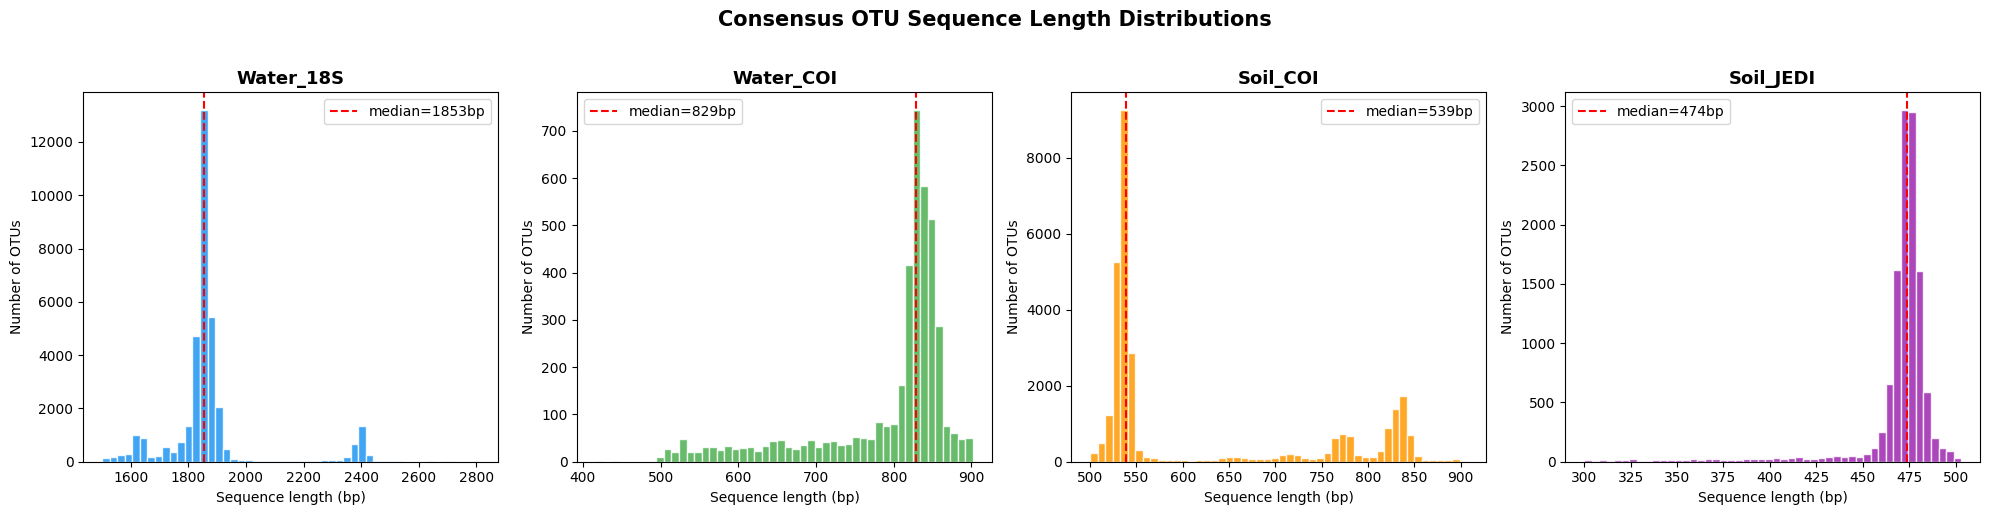

In [6]:
# Histograms of sequence lengths
n_plots = len(seq_lengths)
fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5), squeeze=False)
colors = {"Water_18S": "#2196F3", "Water_COI": "#4CAF50", "Soil_COI": "#FF9800", "Soil_JEDI": "#9C27B0"}

for i, (name, lengths) in enumerate(seq_lengths.items()):
    ax = axes[0, i]
    ax.hist(lengths, bins=50, color=colors.get(name, "steelblue"), edgecolor="white", alpha=0.85)
    ax.axvline(np.median(lengths), color="red", ls="--", lw=1.5, label=f"median={np.median(lengths):.0f}bp")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Sequence length (bp)")
    ax.set_ylabel("Number of OTUs")
    ax.legend()

plt.suptitle("Consensus OTU Sequence Length Distributions", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

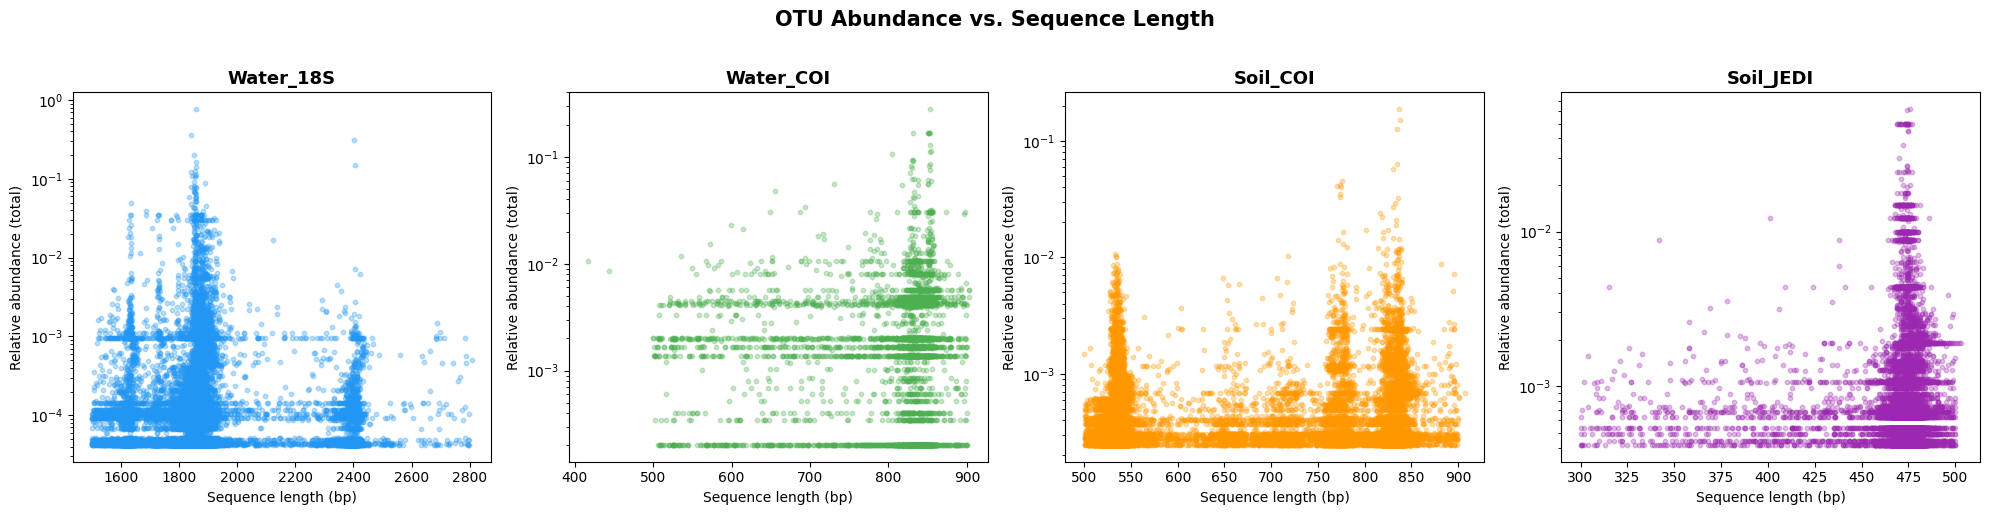

In [7]:
# Abundance vs. sequence length: do longer/shorter OTUs have more reads?
fig, axes = plt.subplots(1, len(seq_lengths), figsize=(5 * len(seq_lengths), 5), squeeze=False)

for i, (name, lengths) in enumerate(seq_lengths.items()):
    ax = axes[0, i]
    df = datasets[name]
    # Match OTUs: consensus FASTA has same order as OTU table by rank
    n = min(len(lengths), len(df))
    ax.scatter(lengths[:n], df["Total_Abundance"].values[:n], alpha=0.3, s=10, color=colors.get(name))
    ax.set_xlabel("Sequence length (bp)")
    ax.set_ylabel("Relative abundance (total)")
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_yscale("log")

plt.suptitle("OTU Abundance vs. Sequence Length", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 4. OTU Abundance Distributions

### 4a. Rank-Abundance Curves
Shows how evenly abundance is distributed across OTUs. Steep curves = dominated by few OTUs.

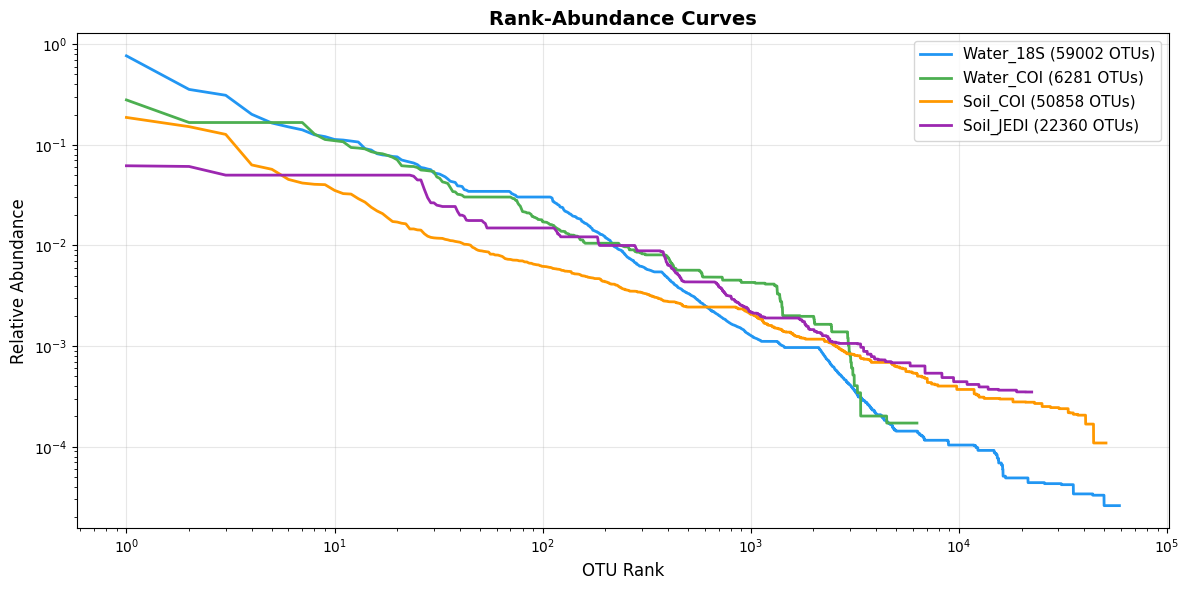

In [8]:
# Rank-abundance curves
fig, ax = plt.subplots(figsize=(12, 6))

for name, df in datasets.items():
    abundances = df["Total_Abundance"].sort_values(ascending=False).values
    ax.plot(range(1, len(abundances) + 1), abundances,
            label=f"{name} ({len(abundances)} OTUs)", color=colors.get(name), lw=2)

ax.set_xlabel("OTU Rank", fontsize=12)
ax.set_ylabel("Relative Abundance", fontsize=12)
ax.set_title("Rank-Abundance Curves", fontsize=14, fontweight="bold")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4b. Per-Sample Read Counts (Raw Abundance Matrices)

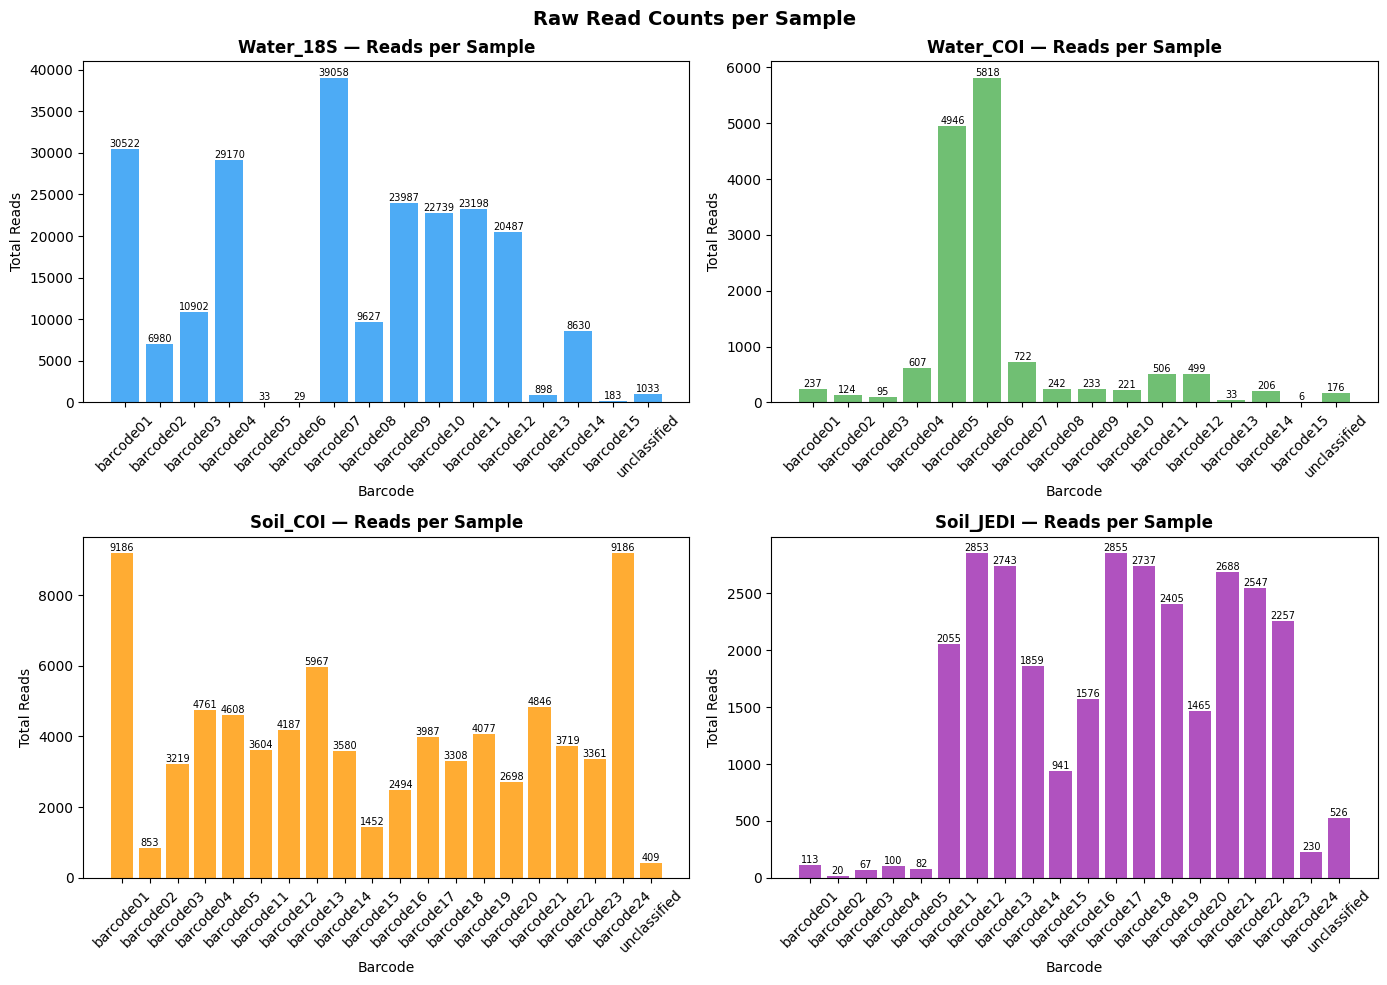

In [9]:
# Per-sample total reads from raw abundance matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, df) in enumerate(abundance.items()):
    ax = axes[i]
    sample_totals = df.sum(axis=0)
    bars = ax.bar(sample_totals.index, sample_totals.values, color=colors.get(name), alpha=0.8)
    ax.set_title(f"{name} — Reads per Sample", fontsize=12, fontweight="bold")
    ax.set_xlabel("Barcode")
    ax.set_ylabel("Total Reads")
    ax.tick_params(axis="x", rotation=45)

    # Annotate totals
    for bar, val in zip(bars, sample_totals.values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                    f"{int(val)}", ha='center', va='bottom', fontsize=7)

plt.suptitle("Raw Read Counts per Sample", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Taxonomic Composition

### 5a. Phylum-Level Composition (Top 10 per dataset)

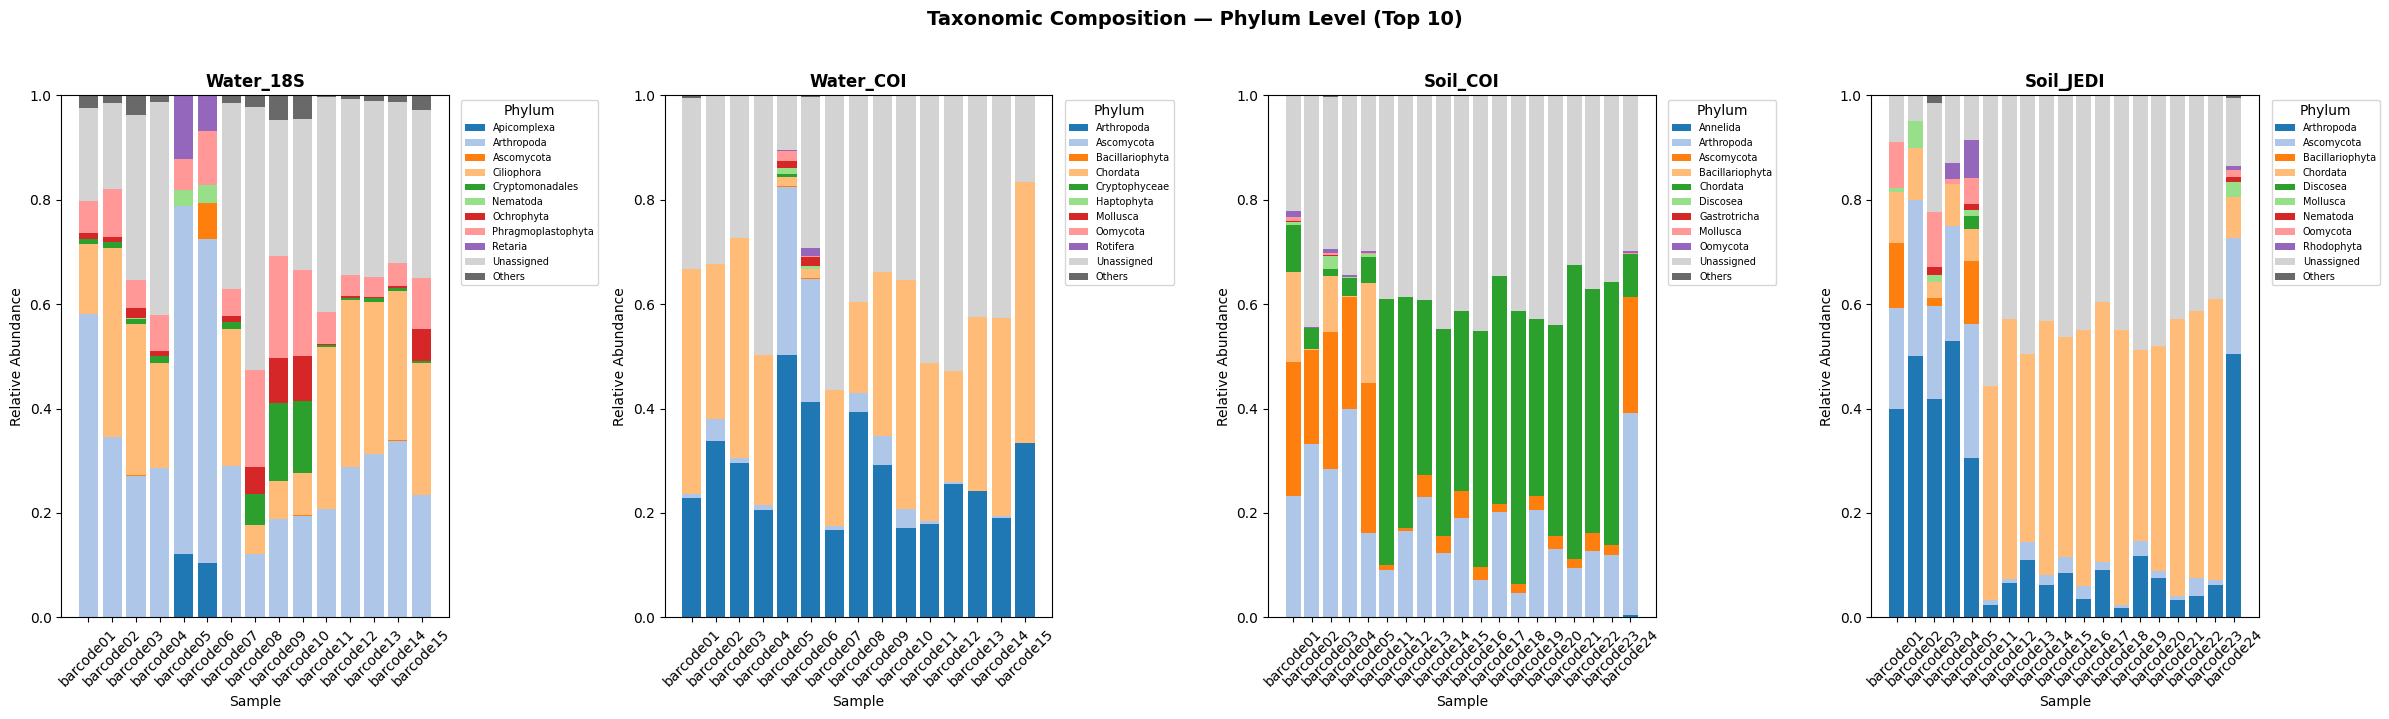

In [ ]:
def plot_taxonomy_stacked_bar(datasets, rank, top_n=10):
    """Stacked bar chart of top N taxa at a given rank across all samples.
    rank: one of 'Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species'
    """
    n_datasets = len(datasets)
    fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 7), squeeze=False)
    
    cmap = plt.cm.tab20
    
    for idx, (name, df) in enumerate(datasets.items()):
        ax = axes[0, idx]
        col = tax_col(name, rank)
        sample_cols = [c for c in df.columns if c.startswith("Sample_") and c != "Sample_unclassified"]
        
        # Fill missing taxonomy
        plot_df = df.copy()
        plot_df[col] = plot_df[col].fillna("Unassigned")
        
        # Aggregate by taxonomy level
        grouped = plot_df.groupby(col)[sample_cols].sum()
        
        # Get top N by total abundance
        totals = grouped.sum(axis=1).sort_values(ascending=False)
        top_taxa = totals.head(top_n).index.tolist()
        
        # Merge remaining into "Others"
        plot_data = grouped.loc[grouped.index.isin(top_taxa)].copy()
        others = grouped.loc[~grouped.index.isin(top_taxa)].sum()
        if others.sum() > 0:
            plot_data.loc["Others"] = others
        
        # Normalize to relative abundance per sample
        plot_data = plot_data.div(plot_data.sum(axis=0), axis=1)
        
        # Assign colors
        color_list = []
        for j, taxon in enumerate(plot_data.index):
            if taxon == "Unassigned":
                color_list.append("#D3D3D3")
            elif taxon == "Others":
                color_list.append("#696969")
            else:
                color_list.append(cmap(j % 20))
        
        # Plot stacked bars
        bottom = np.zeros(len(sample_cols))
        short_labels = [c.replace("Sample_", "") for c in sample_cols]
        for j, taxon in enumerate(plot_data.index):
            vals = plot_data.loc[taxon].values
            ax.bar(short_labels, vals, bottom=bottom, label=taxon, color=color_list[j])
            bottom += vals
        
        db = tax_prefix[name]
        ax.set_title(f"{name} ({db})", fontsize=12, fontweight="bold")
        ax.set_xlabel("Sample")
        ax.set_ylabel("Relative Abundance")
        ax.tick_params(axis="x", rotation=45)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, title=rank)
    
    plt.suptitle(f"Taxonomic Composition — {rank} Level (Top {top_n})",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

plot_taxonomy_stacked_bar(datasets, "Phylum", top_n=10)

### 5b. Family-Level Composition (Top 15)

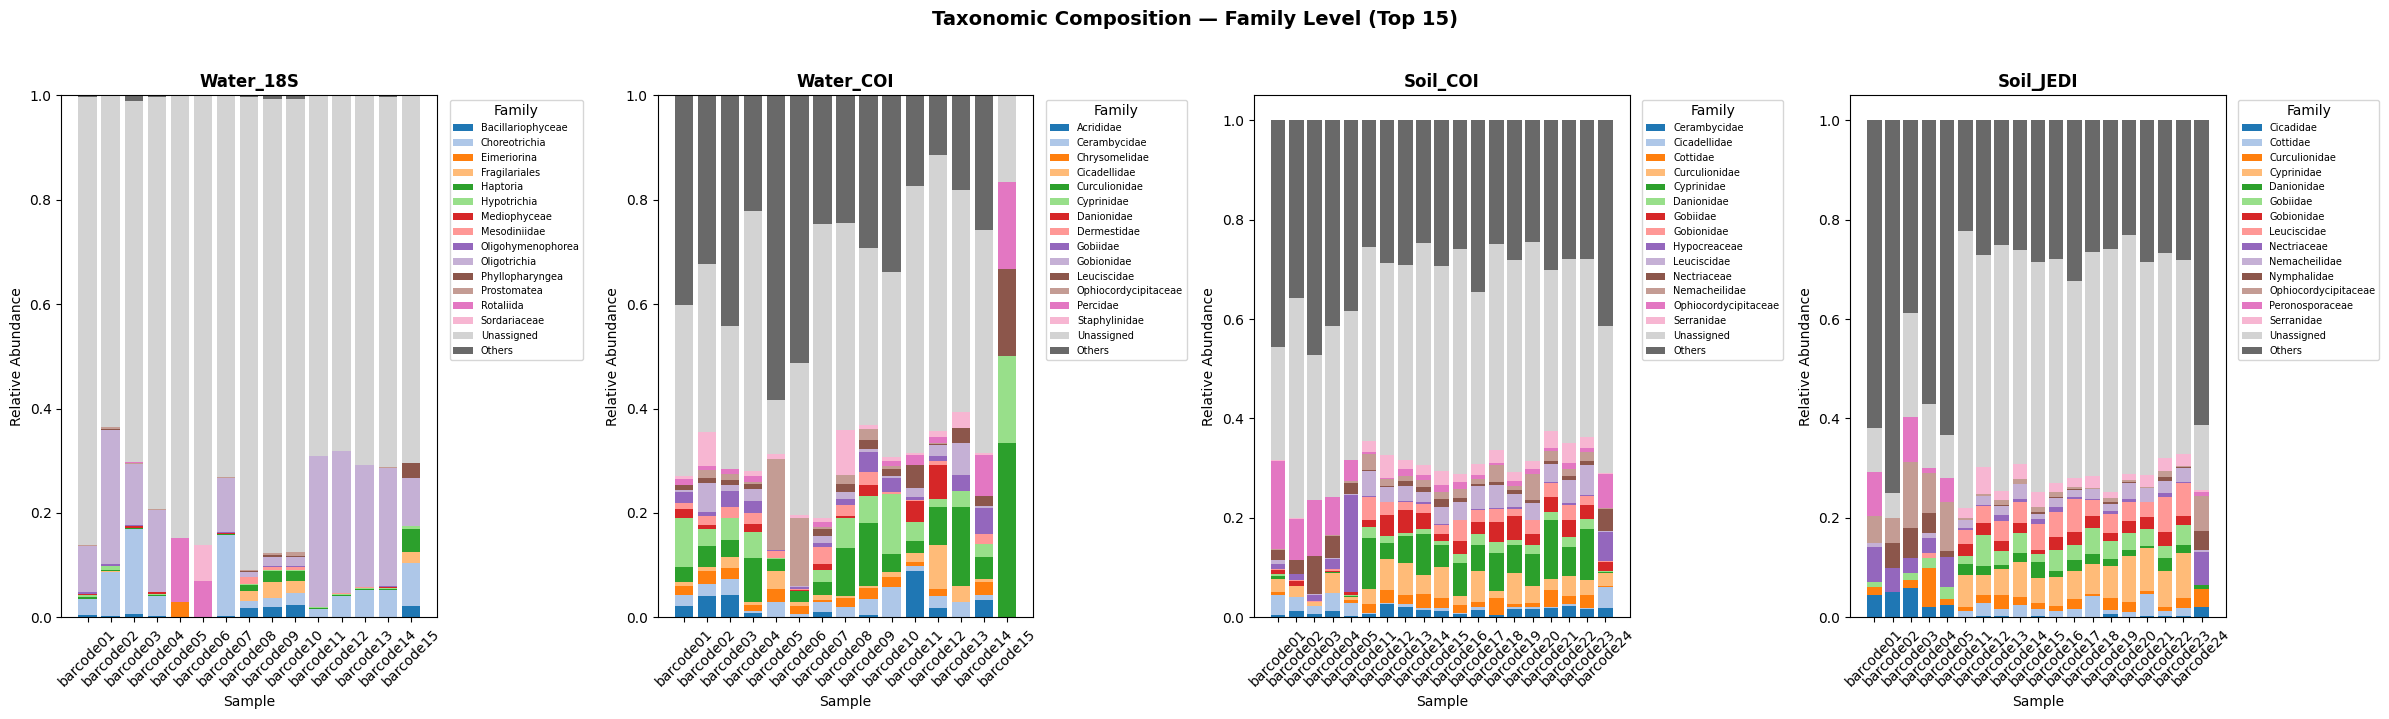

In [ ]:
plot_taxonomy_stacked_bar(datasets, "Family", top_n=15)

### 5c. Taxonomic Assignment Decay (% Unassigned at each level)

Shows the proportion of reads that cannot be classified at progressively finer taxonomic levels.

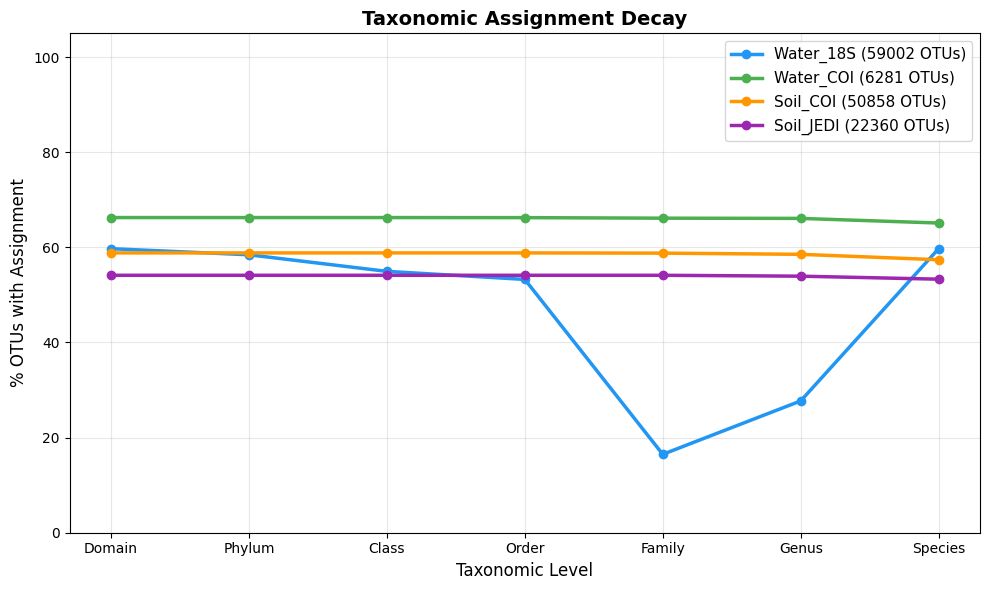

In [ ]:
# Taxonomic assignment decay
fig, ax = plt.subplots(figsize=(10, 6))

for name, df in datasets.items():
    pct_assigned = []
    for rank in TAX_RANKS:
        col = tax_col(name, rank)
        if col in df.columns:
            pct_assigned.append(df[col].notna().mean() * 100)
        else:
            pct_assigned.append(0)
    db = tax_prefix[name]
    ax.plot(TAX_RANKS, pct_assigned, marker="o", lw=2.5,
            label=f"{name} ({db}, {len(df)} OTUs)", color=colors.get(name))

ax.set_ylabel("% OTUs with Assignment", fontsize=12)
ax.set_xlabel("Taxonomic Level", fontsize=12)
ax.set_title("Taxonomic Assignment Decay", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

### 5d. Top 20 Species Identified (Excluding Unassigned)

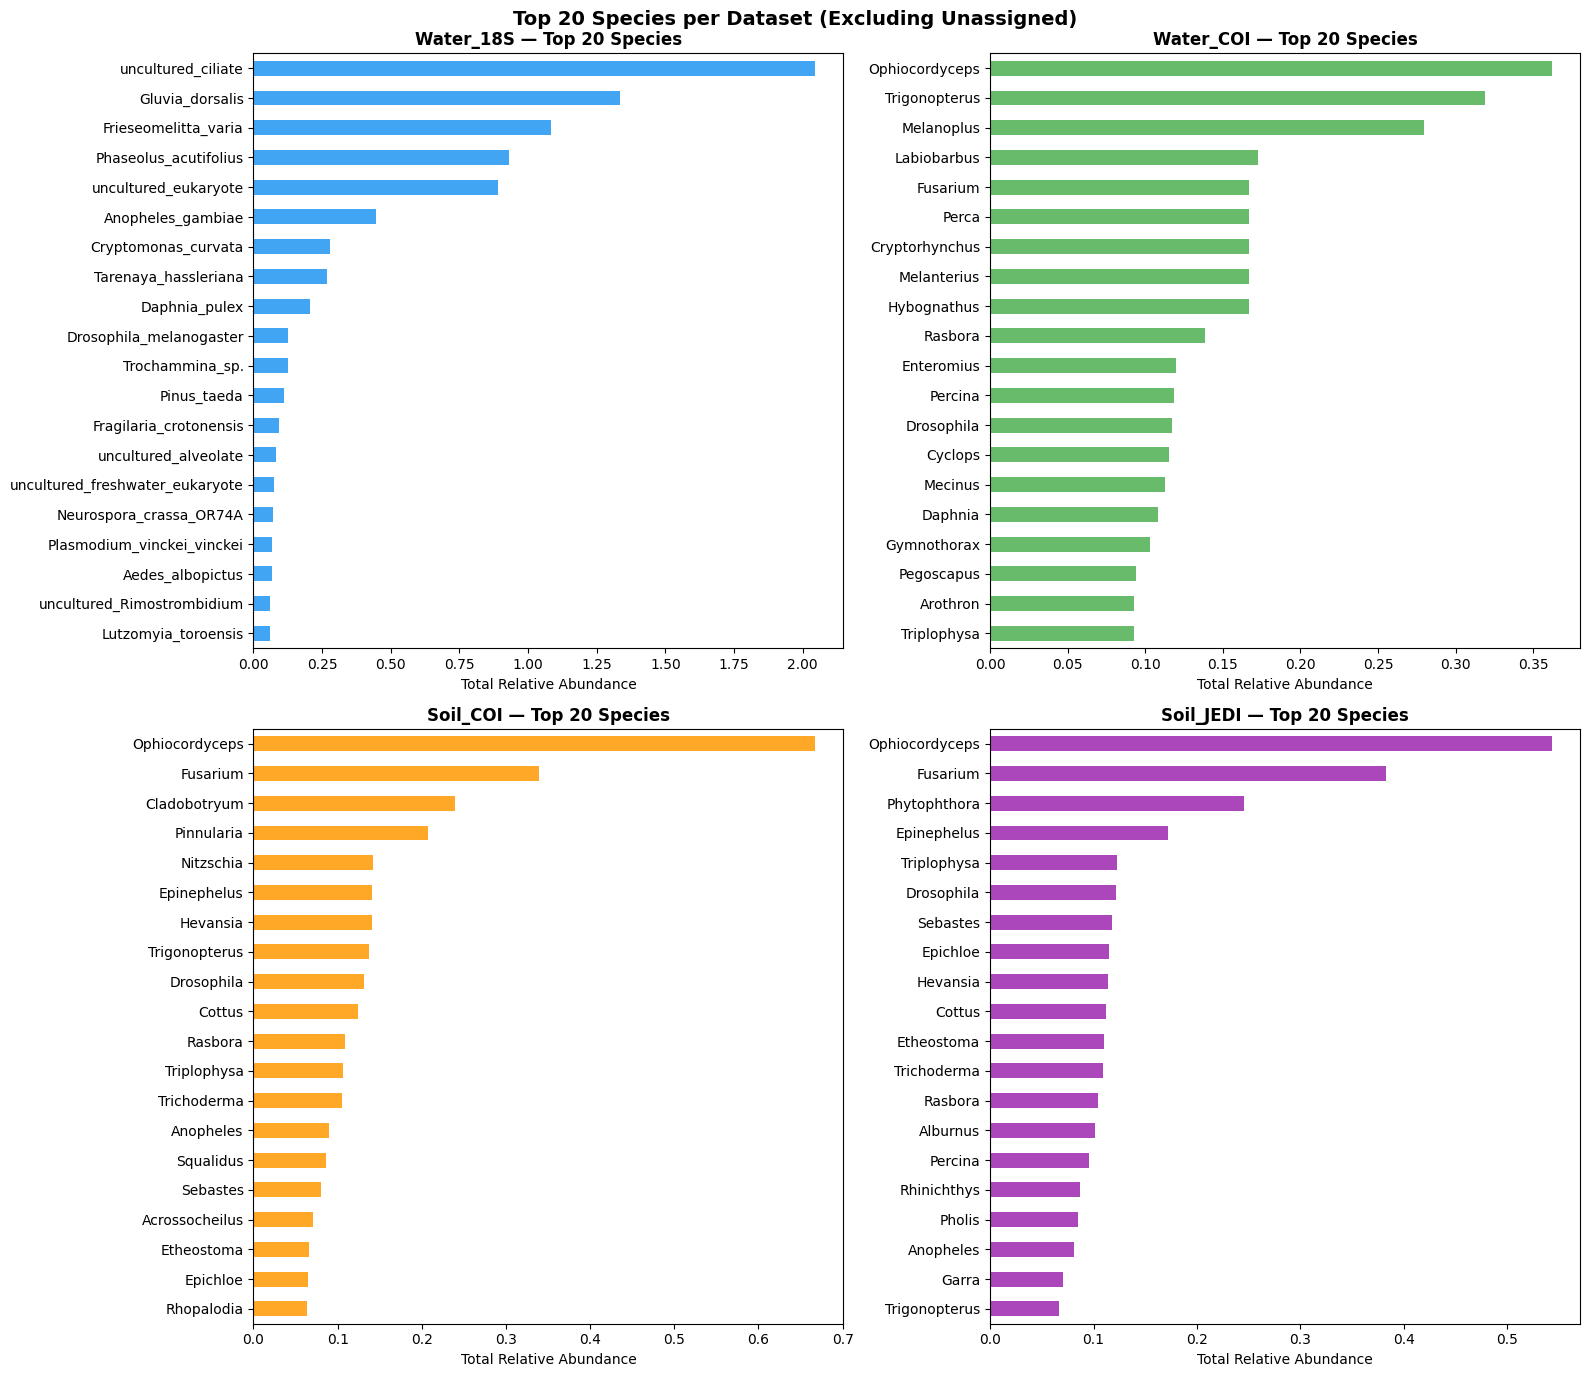

In [ ]:
# Top species per dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    ax = axes[i]
    species_col = tax_col(name, "Species")
    species_df = df[df[species_col].notna()].copy()
    species_agg = species_df.groupby(species_col)["Total_Abundance"].sum().sort_values(ascending=True)
    top20 = species_agg.tail(20)
    
    top20.plot(kind="barh", ax=ax, color=colors.get(name), alpha=0.85)
    db = tax_prefix[name]
    ax.set_title(f"{name} ({db}) — Top 20 Species", fontsize=12, fontweight="bold")
    ax.set_xlabel("Total Relative Abundance")
    ax.set_ylabel("")

plt.suptitle("Top 20 Species per Dataset (Excluding Unassigned)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()